In [5]:
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time
import numpy as np

In [2]:
# cria ambiente
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")

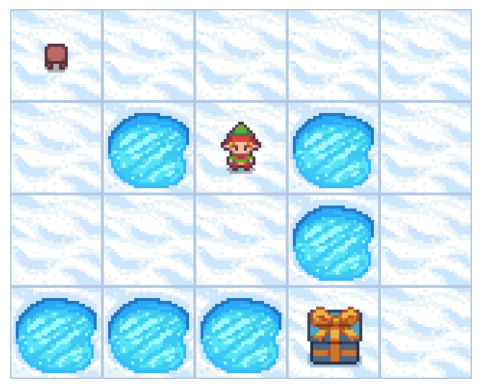

action: RIGHT
reward: 0
new state: 8
info {'prob': 1.0}
*** TERMINATED
Reward final: 0


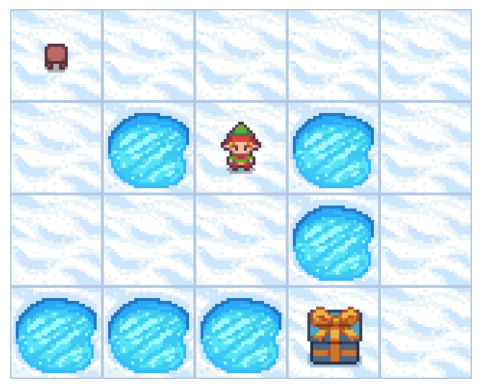

In [50]:
# mapeamento das ações
action_names = {
    0: "LEFT",
    1: "DOWN",
    2: "RIGHT",
    3: "UP"
}


obs, info = env.reset()

done = False

plt.figure()

while not done:

    frame = env.render()

    clear_output(wait=True)
    plt.imshow(frame)
    plt.axis("off")
    display(plt.gcf())

    # política aleatória
    action = env.action_space.sample()
    print("action:", action_names[action])

    new_state, reward, terminated, truncated, info = env.step(action)


    print("reward:", reward)
    print("new state:", new_state)
    print("info", info)

    done = terminated or truncated

    if terminated:
      print("*** TERMINATED")
    if truncated:
      print ("*** TRUNCATED")

    time.sleep(4)

env.close()

print("Reward final:", reward)

In [68]:
import numpy as np

alpha = 0.1
gamma = 0.99

epsilon = 1.0
epsilon_decay = 0.999
epsilon_min = 0.05

episodes = 200000

q_table = np.zeros((env.observation_space.n, env.action_space.n))

for episode in range(episodes):

    state, info = env.reset()
    done = False

    while not done:

        # epsilon-greedy
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.random.choice(
                np.where(q_table[state] == np.max(q_table[state]))[0]
            )


        new_state, reward, terminated, truncated, info = env.step(action)

        # Q-learning update
        q_table[state, action] += alpha * (
            reward +
            gamma * np.max(q_table[new_state]) -
            q_table[state, action]
        )

        state = new_state
        done = terminated or truncated

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

print("Treinamento finalizado")

Treinamento finalizado


In [69]:
q_table

array([[0.88638487, 0.89533825, 0.        , 0.88638487],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.93206535, 0.95099005, 0.94148015],
       [0.94148015, 0.        , 0.96059601, 0.95099005],
       [0.95099005, 0.970299  , 0.96059601, 0.96059601],
       [0.89533825, 0.90438208, 0.        , 0.88638487],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.92274469, 0.        , 0.94148015],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.9801    , 0.970299  , 0.96059601],
       [0.90438208, 0.        , 0.91351725, 0.89533825],
       [0.90438208, 0.        , 0.92274469, 0.        ],
       [0.91351725, 0.        , 0.        , 0.93206535],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.99      , 0.9801    , 0.970299  ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        ,

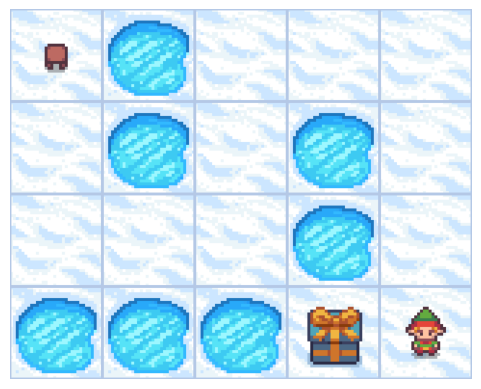

action: LEFT
reward: 1
new state: 18
Reward final: 1


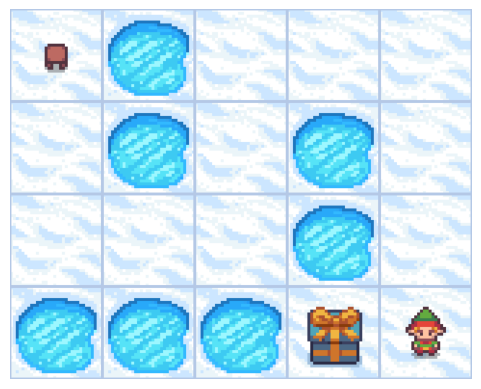

In [70]:
state, info = env.reset()
done = False

plt.figure()

while not done:

    frame = env.render()

    clear_output(wait=True)
    plt.imshow(frame)
    plt.axis("off")
    display(plt.gcf())

    action = np.argmax(q_table[state])

    print("action:", action_names[action])

    new_state, reward, terminated, truncated, info = env.step(action)

    print("reward:", reward)
    print("new state:", new_state)

    state = new_state
    done = terminated or truncated

    time.sleep(1)

env.close()
print("Reward final:", reward)

In [40]:
env = gym.make("FrozenLake-v1", render_mode="rgb_array", is_slippery=False)


In [53]:
custom_map = [
    "SHFFF",
    "FHFHF",
    "FFFHF",
    "HHHGF"
]

env = gym.make(
    "FrozenLake-v1",
    desc=custom_map,
    render_mode="rgb_array",
    is_slippery=False
)

env

<TimeLimit<OrderEnforcing<PassiveEnvChecker<FrozenLakeEnv<FrozenLake-v1>>>>>